# Time Series Data Visualization - ETTh1 Dataset
## Comprehensive analysis and visualization of hourly electricity load data

### 1. Import Libraries and Load Data

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load data
df = pd.read_csv('ETT-small/ETTh1.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (17420, 7)

First few rows:
                      HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
date                                                                    
2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17420 entries, 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    17420 non-null  float64
 1   HULL    17420 non-null  float64
 2   MUFL    17420 non-null  float64
 3   MULL    17420 non-null  float64
 4   LUFL    17420 non-null  float64
 5   LULL    17420 non-null  flo

### 2. Time Series Overview Plot

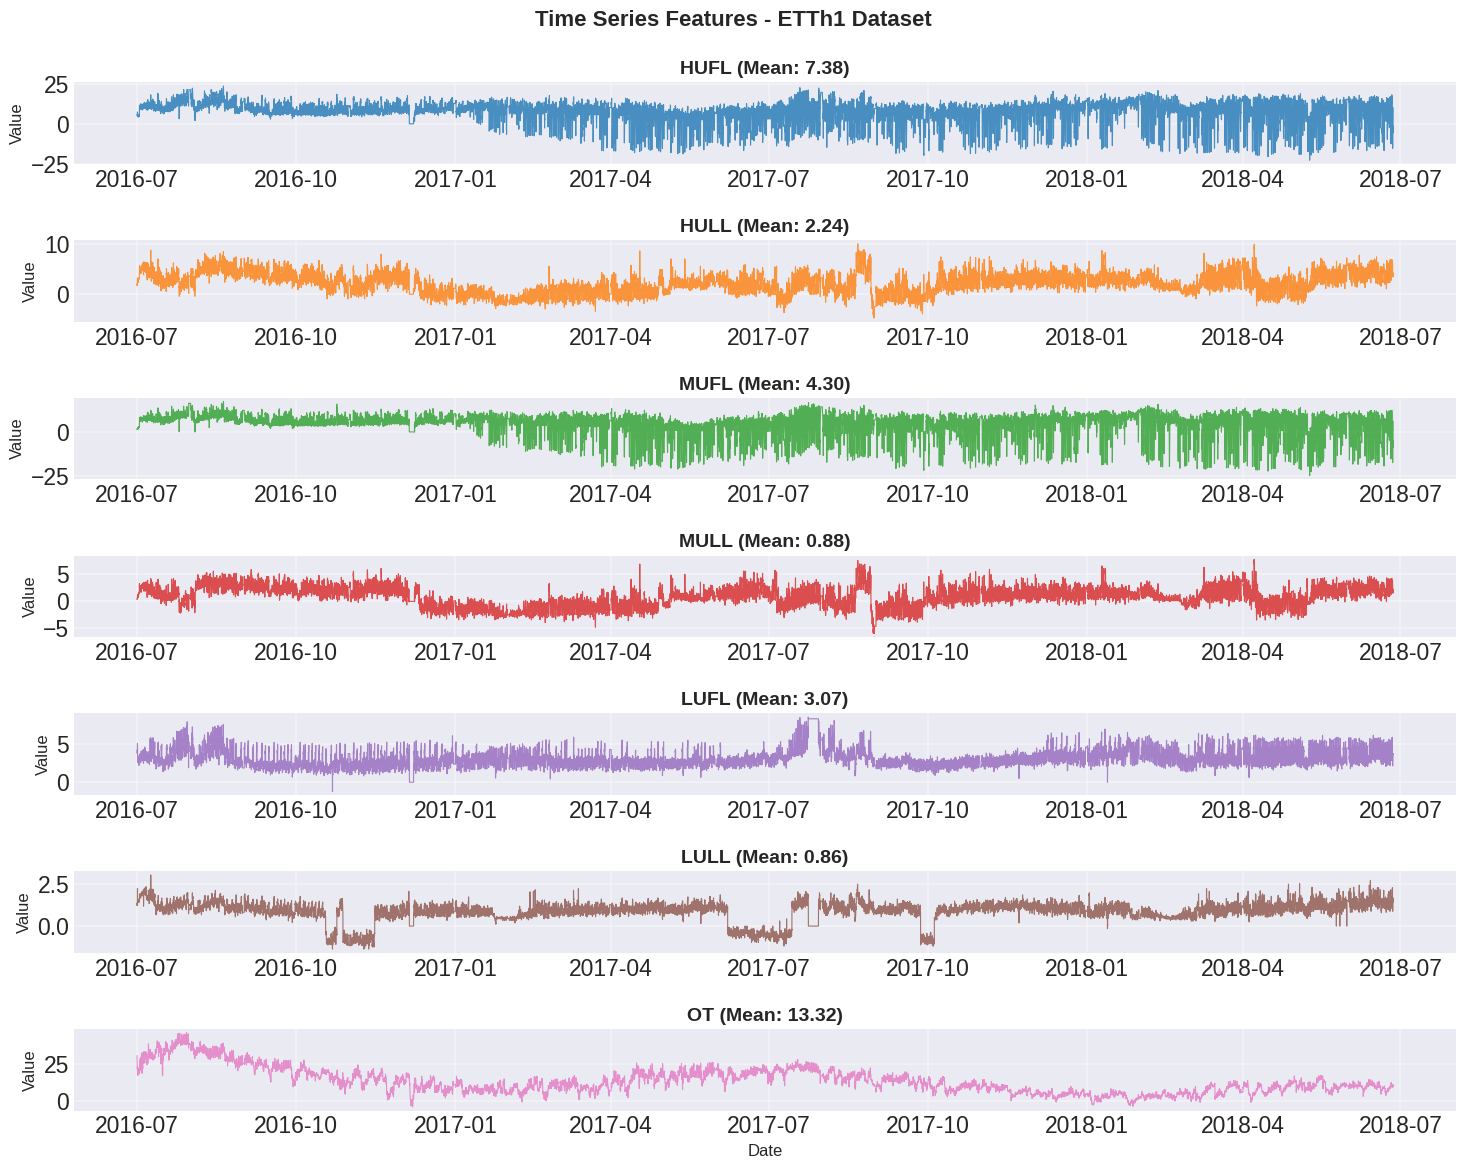

In [48]:
# Plot all features
fig, axes = plt.subplots(7, 1, figsize=(15, 12))
fig.suptitle('Time Series Features - ETTh1 Dataset', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    axes[idx].plot(df.index, df[col], color=plt.cm.tab10(idx), linewidth=0.8, alpha=0.8)
    axes[idx].set_title(f'{col} (Mean: {df[col].mean():.2f})', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.tight_layout()
plt.show()

### 3. Distribution Analysis

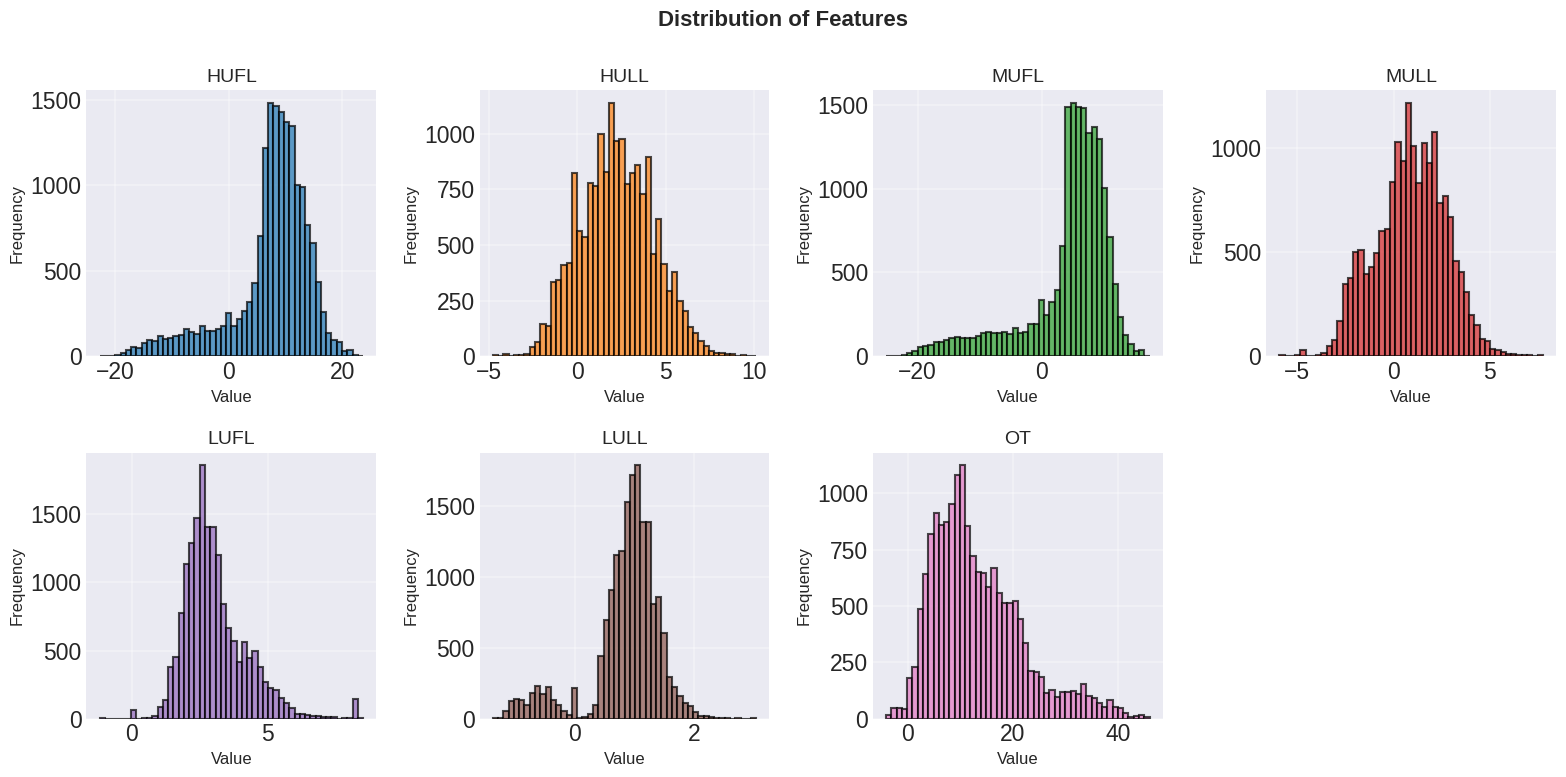

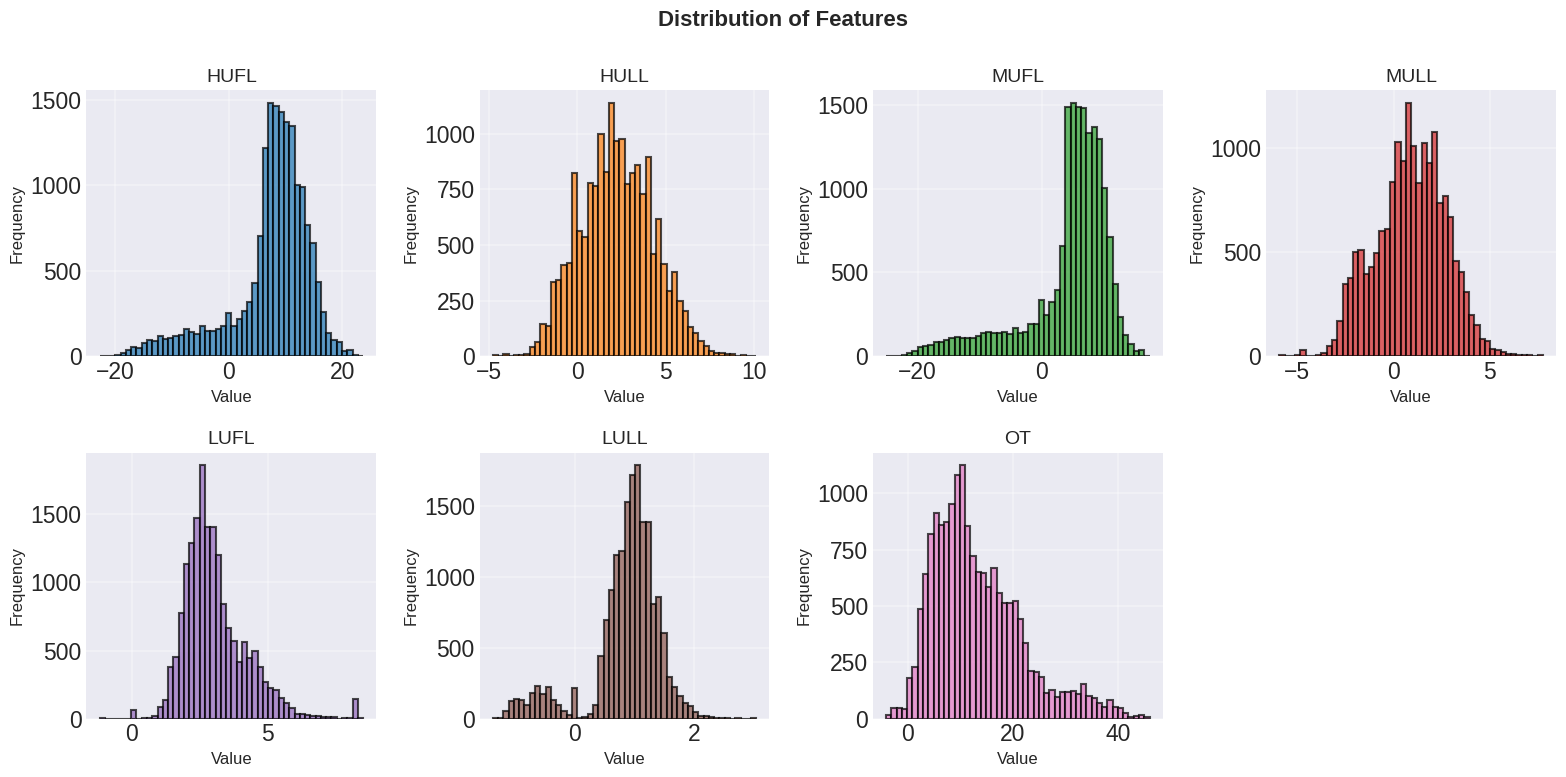

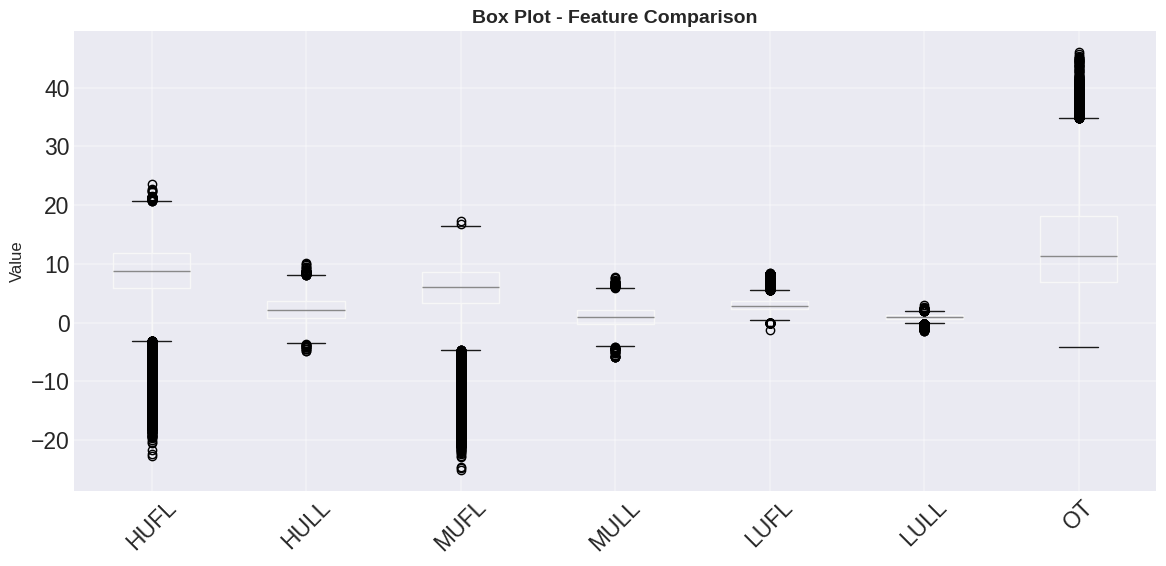

In [49]:
# Distribution plot for all features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of Features', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, color=plt.cm.tab10(idx), alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Hide the extra subplot
axes[-1].set_visible(False)
fig.tight_layout()
plt.show()

# Box plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(ax=ax)
ax.set_title('Box Plot - Feature Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### 4. Correlation Analysis

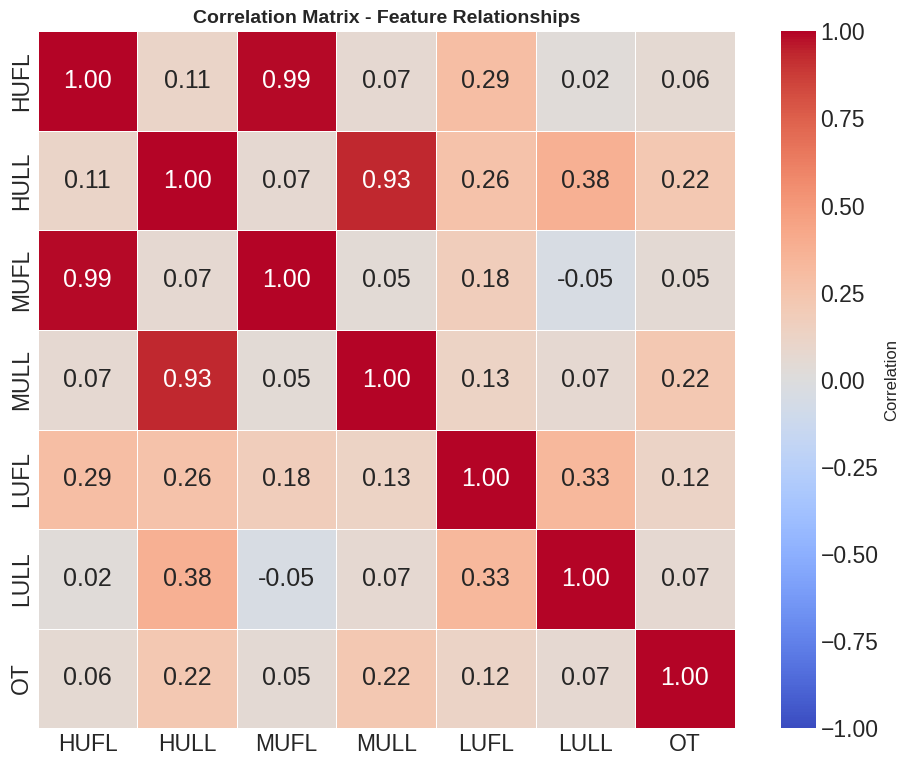


Correlation with OT (Target):
OT      1.000000
HULL    0.224354
MULL    0.220004
LUFL    0.118836
LULL    0.067455
HUFL    0.059916
MUFL    0.050854
Name: OT, dtype: float64


In [50]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'}, 
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation Matrix - Feature Relationships', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Print correlation with target (OT)
print("\nCorrelation with OT (Target):")
print(corr_matrix['OT'].sort_values(ascending=False))

### 5. Seasonal Decomposition (for OT feature)

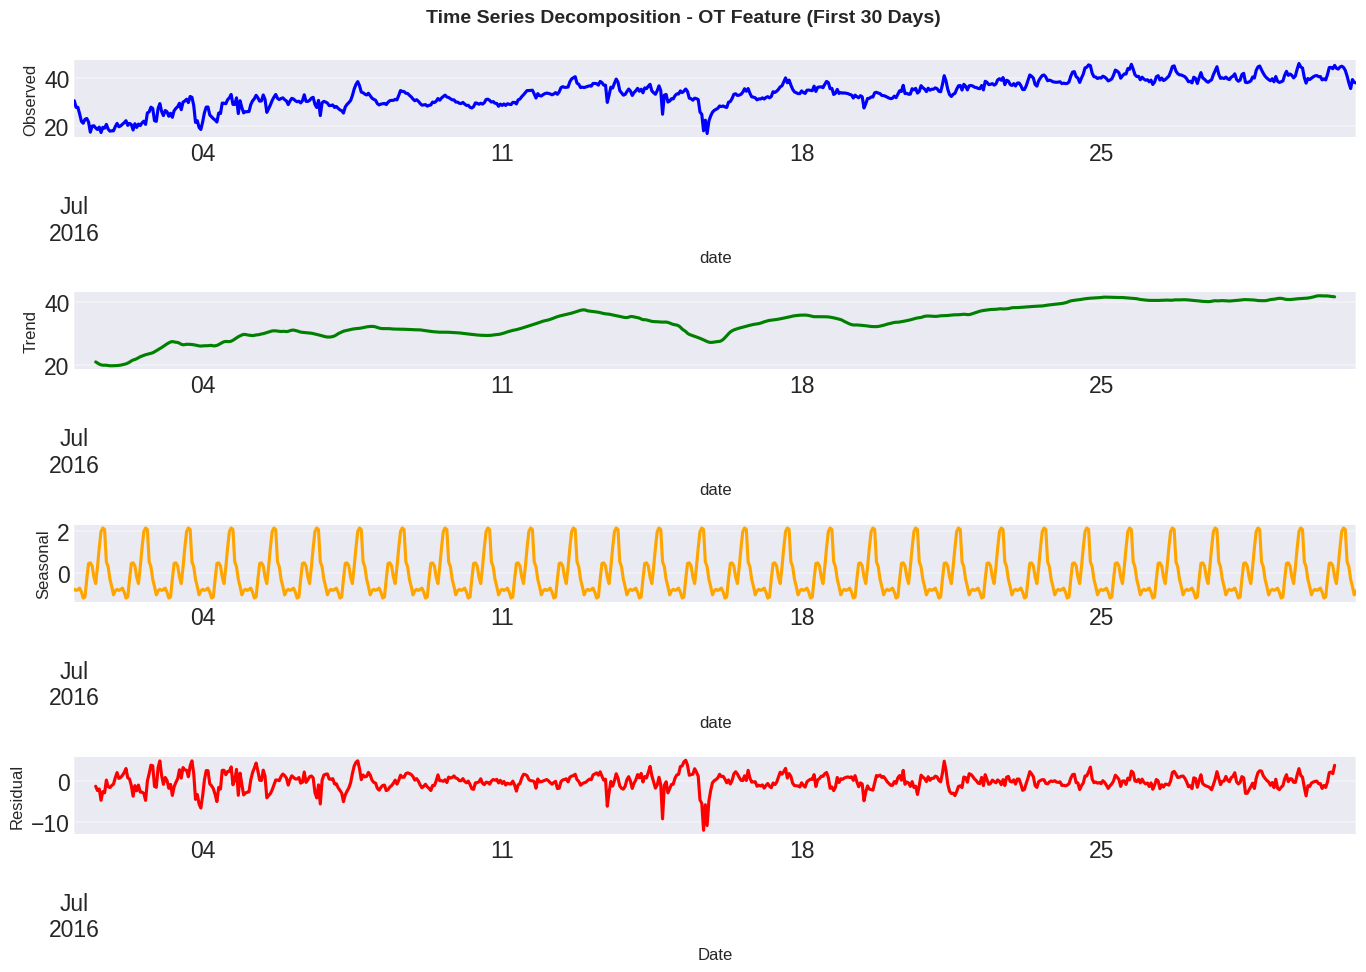

In [51]:
# Seasonal decomposition (using a sample for efficiency)
# Using period = 24 for hourly data (daily cycle)
sample_data = df['OT'].iloc[:720]  # First 30 days

decomposition = seasonal_decompose(sample_data, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Time Series Decomposition - OT Feature (First 30 Days)', fontsize=14, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='blue')
axes[0].set_ylabel('Observed')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### 6. Autocorrelation Analysis (ACF/PACF)

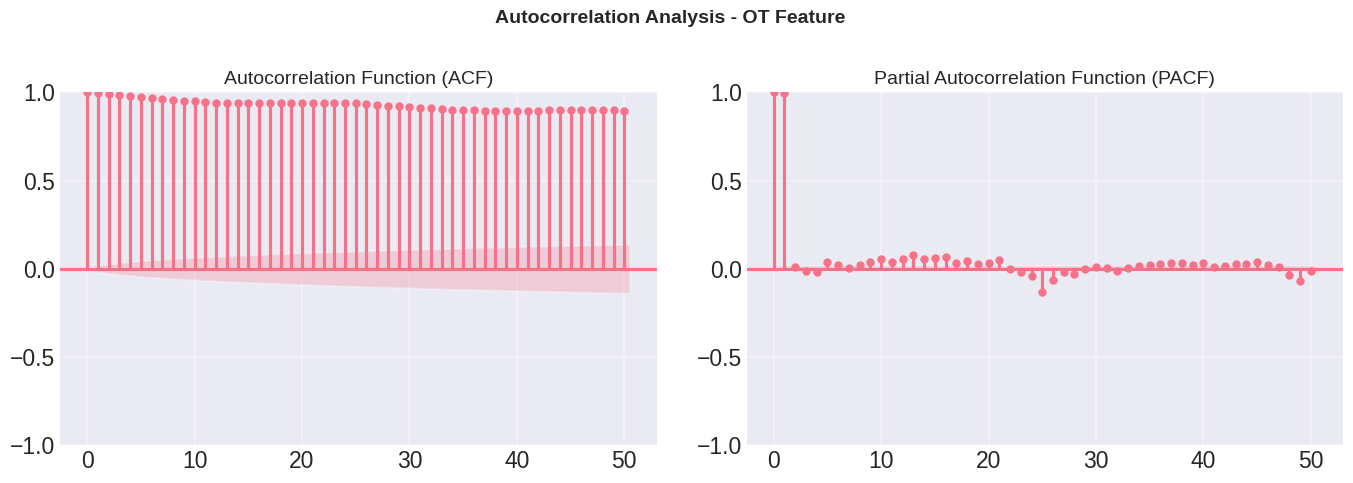

In [52]:
# ACF plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autocorrelation Analysis - OT Feature', fontsize=14, fontweight='bold')

# ACF
plot_acf(df['OT'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(df['OT'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### 7. Rolling Statistics Analysis

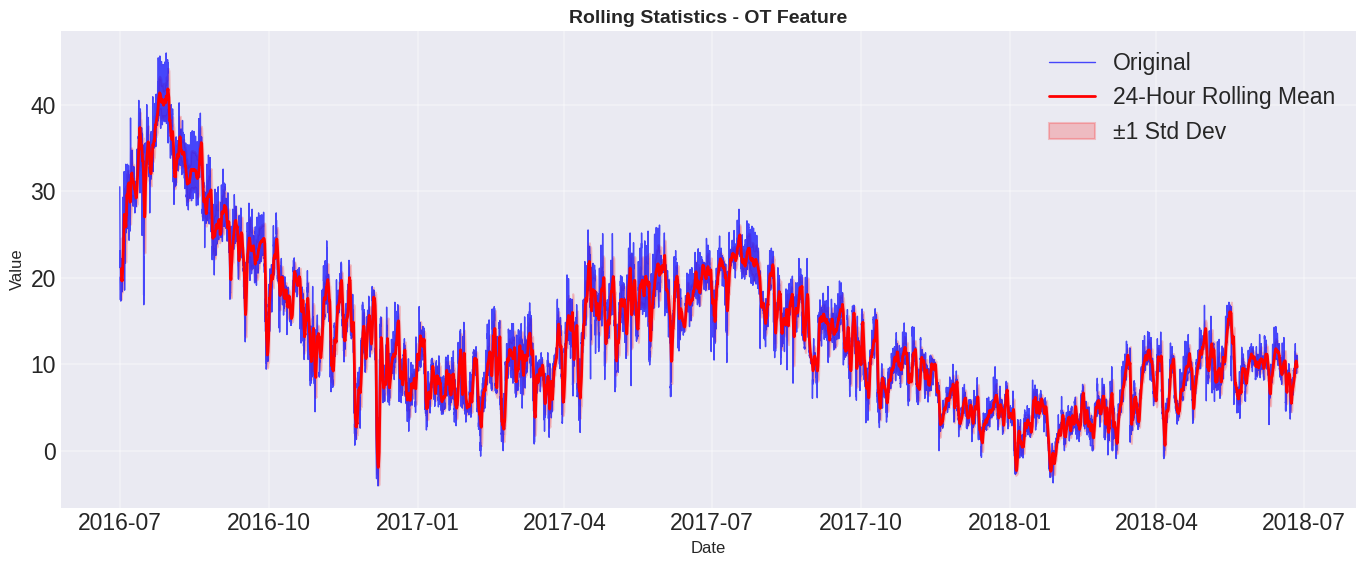

In [53]:
# Rolling mean and standard deviation
rolling_mean = df['OT'].rolling(window=24).mean()  # 24-hour rolling mean
rolling_std = df['OT'].rolling(window=24).std()    # 24-hour rolling std

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['OT'], label='Original', color='blue', alpha=0.7, linewidth=1)
ax.plot(df.index, rolling_mean, label='24-Hour Rolling Mean', color='red', linewidth=2)
ax.fill_between(df.index, 
                 rolling_mean - rolling_std, 
                 rolling_mean + rolling_std, 
                 alpha=0.2, color='red', label='±1 Std Dev')
ax.set_title('Rolling Statistics - OT Feature', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 8. Hourly Pattern Analysis

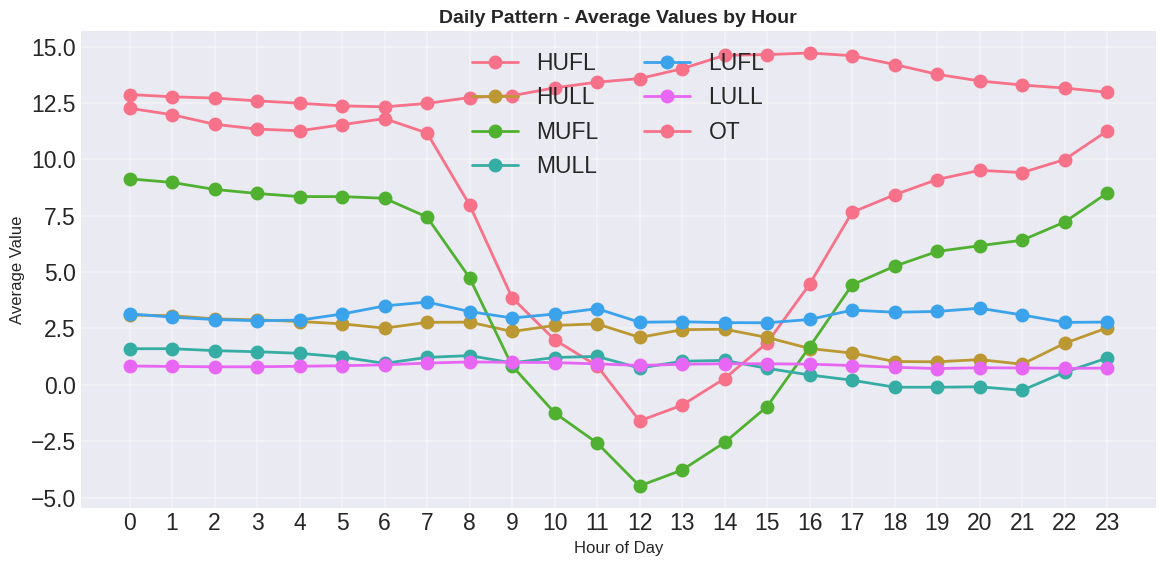

In [54]:
# Add hour and day information
df_temp = df.copy()
df_temp['hour'] = df_temp.index.hour
df_temp['day'] = df_temp.index.day

# Average by hour
hourly_avg = df_temp.groupby('hour').agg({col: 'mean' for col in df.columns})

fig, ax = plt.subplots(figsize=(12, 6))
for col in df.columns:
    ax.plot(hourly_avg.index, hourly_avg[col], marker='o', label=col, linewidth=2)

ax.set_title('Daily Pattern - Average Values by Hour', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Value')
ax.set_xticks(range(0, 24))
ax.legend(loc='best', ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 9. Heatmap - Daily Patterns

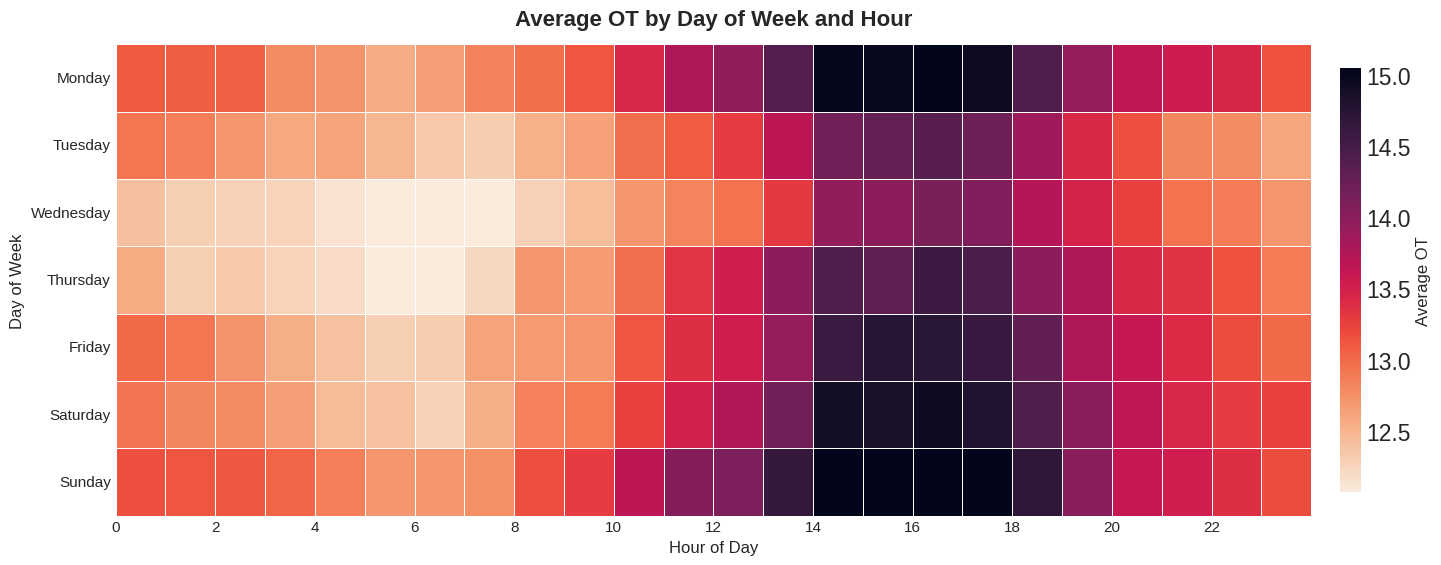

In [55]:
# Create a cleaner, more presentation-friendly heatmap for OT
# Use day-of-week and hour-of-day to highlight recurring weekly structure
heat_df = df_temp.copy()
heat_df['day_name'] = heat_df.index.day_name()

hour_day_order = list(range(24))
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    heat_df.pivot_table(
        values='OT',
        index='day_name',
        columns='hour',
        aggfunc='mean'
    )
    .reindex(dow_order)
    .reindex(columns=hour_day_order)
)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#fcfcfc')

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='rocket_r',
    linewidths=0.6,
    linecolor='white',
    square=False,
    robust=True,
    cbar_kws={'label': 'Average OT', 'shrink': 0.9, 'pad': 0.02}
)

ax.set_title('Average OT by Day of Week and Hour', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([str(i) for i in range(0, 24, 2)], rotation=0)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()
plt.show()

In [60]:
from IPython.display import display

# Create supervised time series samples and show only before/after tables

def create_ts_data(data, window_size=25, target_size=1, target_col="OT"):
    df_local = data.copy()

    all_cols = [col for col in df_local.columns if col != "date"]
    new_columns = {}

    for i in range(1, window_size):
        for col in all_cols:
            new_columns[f"{col}_lag_{i}"] = df_local[col].shift(i)

    for i in range(target_size):
        new_columns[f"target_{i + 1}"] = df_local[target_col].shift(-i - 1)

    new_cols_df = pd.DataFrame(new_columns, index=df_local.index)
    df_local = pd.concat([df_local, new_cols_df], axis=1)
    df_local = df_local.dropna()

    return df_local

before_df = df.reset_index().copy()
after_df = create_ts_data(before_df, window_size=25, target_size=1, target_col="OT")

print("Shape before processing:", before_df.shape)
print("Shape after processing:", after_df.shape)

print("\nBảng dữ liệu trước khi xử lý:")
display(before_df.head(5))

print("\nBảng dữ liệu sau khi xử lý:")
display(after_df[["date", "OT", "OT_lag_1", "OT_lag_24", "target_1"]].head(5))

Shape before processing: (17420, 8)
Shape after processing: (17395, 177)

Bảng dữ liệu trước khi xử lý:


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000



Bảng dữ liệu sau khi xử lý:


,date,OT,OT_lag_1,OT_lag_24,target_1
24,2016-07-02 00:00:00,21.104000,19.768000,30.531000,19.697001
25,2016-07-02 01:00:00,19.697001,21.104000,27.787001,20.049000
26,2016-07-02 02:00:00,20.049000,19.697001,27.787001,20.752001
27,2016-07-02 03:00:00,20.752001,20.049000,25.044001,21.385000
28,2016-07-02 04:00:00,21.385000,20.752001,21.948000,22.230000


### 10. First Differences (Stationarity Check)

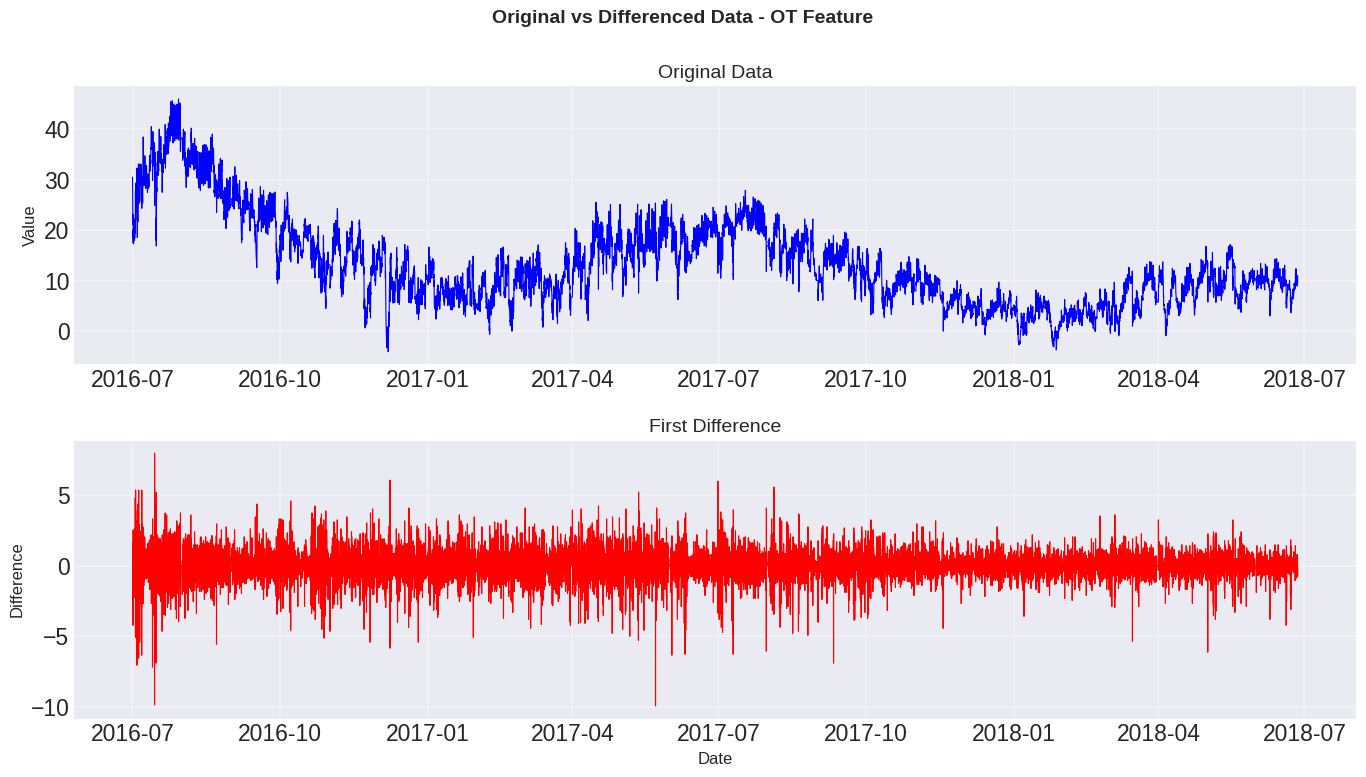

Original Mean: 13.3247, Std: 8.5669
Differenced Mean: -0.0012, Std: 0.9182


In [56]:
# Calculate first differences
df_diff = df.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Original vs Differenced Data - OT Feature', fontsize=14, fontweight='bold')

# Original data
axes[0].plot(df.index, df['OT'], color='blue', linewidth=0.8)
axes[0].set_title('Original Data')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Differenced data
axes[1].plot(df_diff.index, df_diff['OT'], color='red', linewidth=0.8)
axes[1].set_title('First Difference')
axes[1].set_ylabel('Difference')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"Original Mean: {df['OT'].mean():.4f}, Std: {df['OT'].std():.4f}")
print(f"Differenced Mean: {df_diff['OT'].mean():.4f}, Std: {df_diff['OT'].std():.4f}")

### 11. Comparative Analysis - All Features

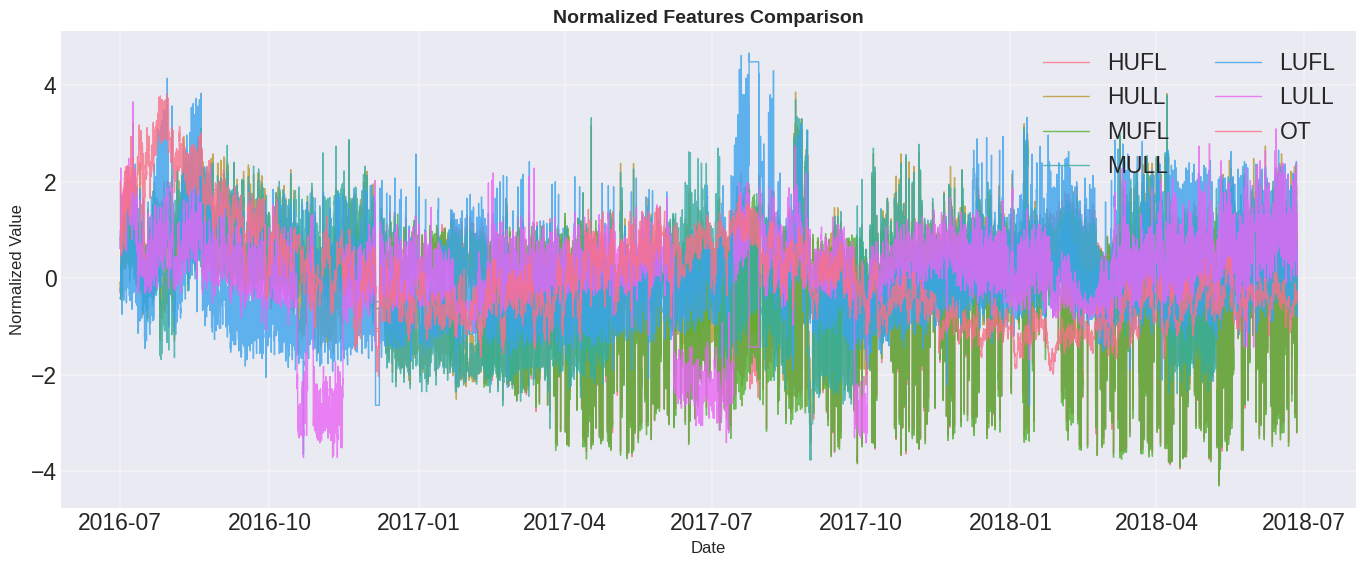

In [57]:
# Normalize data for comparison
df_normalized = (df - df.mean()) / df.std()

fig, ax = plt.subplots(figsize=(14, 6))
for col in df_normalized.columns:
    ax.plot(df_normalized.index, df_normalized[col], label=col, linewidth=1, alpha=0.8)

ax.set_title('Normalized Features Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value')
ax.legend(loc='best', ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 12. Data Quality Summary

In [58]:
# Data quality report
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)
print(f"\nTotal Records: {len(df):,}")
print(f"Date Range: {df.index.min()} to {df.index.max()}")
print(f"Duration: {(df.index.max() - df.index.min()).days} days")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(f"Total duplicates: {df.duplicated().sum()}")

print("\nData Type Summary:")
print(df.dtypes)

print("\n" + "=" * 60)
print("Statistical Summary")
print("=" * 60)
print(df.describe().T)

print("\nSkewness and Kurtosis:")
for col in df.columns:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col:6s} - Skewness: {skew:7.4f}, Kurtosis: {kurt:7.4f}")

DATA QUALITY REPORT

Total Records: 17,420
Date Range: 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Duration: 725 days

Missing Values:
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

Duplicate Records:
Total duplicates: 338

Data Type Summary:
HUFL    float64
HULL    float64
MUFL    float64
MULL    float64
LUFL    float64
LULL    float64
OT      float64
dtype: object

Statistical Summary
        count       mean       std        min    25%     50%     75%  \
HUFL  17420.0   7.375141  7.067744 -22.705999  5.827   8.774  11.788   
HULL  17420.0   2.242242  2.042342  -4.756000  0.737   2.210   3.684   
MUFL  17420.0   4.300239  6.826978 -25.087999  3.296   5.970   8.635   
MULL  17420.0   0.881568  1.809293  -5.934000 -0.284   0.959   2.203   
LUFL  17420.0   3.066062  1.164506  -1.188000  2.315   2.833   3.625   
LULL  17420.0   0.856932  0.599552  -1.371000  0.670   0.975   1.218   
OT    17420.0  13.324672  8.566946  -4.080000  6.964  11.396  18.079  